# LSTM para prediccion de RUL en NASA CMAPSS FD001

Este notebook entrena una red neuronal LSTM de regresion para predecir `RUL` a partir de secuencias temporales de sensores. El nivel de riesgo no se predice directamente: se deriva despues a partir del RUL predicho para construir un sistema de alertas y calcular metricas de clasificacion.

## 1. Importacion de librerias

Se importan las librerias necesarias para manipulacion de datos, generacion de secuencias, entrenamiento con TensorFlow/Keras, metricas y visualizacion.

In [93]:
# Instalando dependencias
# %pip install --upgrade pip
# %pip install -r ../../requirements.txt

In [29]:
# Imports
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Métricas de evaluación
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Estilos gráficas
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Carga de datos

In [30]:
# La funcion "find_project_root" permite ejecutar el notebook tanto desde la raiz del proyecto como desde `./lstm/src`
def find_root_proyecto() -> Path:
    """Devuelve la carpeta lstm del proyecto aunque el notebook se ejecute desde otra ruta."""
    actual = Path.cwd().resolve()

    if actual.name == "lstm":
        return actual

    if (actual / "lstm").exists():
        return actual / "lstm"

    for parent in actual.parents:
        if parent.name == "lstm":
            return parent
        if (parent / "lstm").exists():
            return parent / "lstm"

    raise FileNotFoundError("No se encontro la carpeta 'lstm'. Revisa la ruta de ejecucion.")


ROOT_DIR = find_root_proyecto()
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs"
MODEL_DIR = ROOT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "TRAIN_FD001_FINAL.csv"
TEST_PATH = DATA_DIR / "TEST_FD001_FINAL.csv"

# sep=None detecta automaticamente separadores frecuentes como ',' o ';'.
df_1 = pd.read_csv(TRAIN_PATH, sep=None, engine="python")
df_2 = pd.read_csv(TEST_PATH, sep=None, engine="python")

**Vamos a unir los dos dataframes en uno para hacer una separación distinta de train/val/test. Esto es porque el dataset original tiene una separación fija que no es ideal para evaluar la capacidad de generalización del modelo a nuevos motores.**


In [31]:
df_2["unit_number"] = df_2["unit_number"] + df_1["unit_number"].max()
df = pd.concat([df_1, df_2], ignore_index = True)
print(f"Shape del dataframe combinado: {df.shape}") 

#Ahora dividimos el dataframe combinado en df_train, df_val y df_test de forma que contengan 70 motores, 15 motores y 15 motores respectivamente.
motor_ids = df['unit_number'].unique()
random.shuffle(motor_ids)

train_ids = motor_ids[:70]
val_ids = motor_ids[70:85]
test_ids = motor_ids[85:100]

df_train = df[df['unit_number'].isin(train_ids)]
df_val = df[df['unit_number'].isin(val_ids)]
df_test = df[df['unit_number'].isin(test_ids)]

print(f"Root del proyecto: {ROOT_DIR}")
print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape:  {df_test.shape}")
print("Motores en train:", df_train['unit_number'].unique())
print("Motores en validation:", df_val['unit_number'].unique())
print("Motores en test:", df_test['unit_number'].unique())

Shape del dataframe combinado: (33727, 22)
Root del proyecto: /content/TFM_Mantenimiento_Predictivo/lstm
Train shape: (11820, 22)
Validation shape: (2462, 22)
Test shape:  (2674, 22)
Motores en train: [  1   4   5   9  17  20  22  26  27  28  35  55  59  72  76  78  88  91
  92  93  96  11  30  32  38  42  49  58  63  67  69  95 102 103 104 106
 107 111 112 114 116 122 123 126 127 129 131 136 137 145 146 154 157 159
 160 161 162 163 168 171 172 173 177 178 187 188 193 194 195 196]
Motores en validation: [ 94  18  39  68  74  75 105 110 119 134 143 147 166 180 197]
Motores en test: [ 34  52  61  10  36  56  73 101 113 124 141 149 156 176 185]


## 3. Seleccion de Features y Target
Seleccion de columnas feature y Target = "RUL"

In [32]:
print(df_train.columns)

Index(['unit_number', 'time_in_cycles', 'setting_1_scaled', 'setting_2_scaled',
       'sensor_2_scaled', 'sensor_3_scaled', 'sensor_4_scaled',
       'sensor_7_scaled', 'sensor_8_scaled', 'sensor_9_scaled',
       'sensor_11_scaled', 'sensor_12_scaled', 'sensor_13_scaled',
       'sensor_14_scaled', 'sensor_15_scaled', 'sensor_17_scaled',
       'sensor_20_scaled', 'sensor_21_scaled', 'RUL', 'RUL_capado',
       'risk_level', 'risk_level_capped'],
      dtype='object')


In [33]:
FEATURES = [col for col in df_train.columns if col not in ['unit_number', 'time_in_cycles', 'RUL', 'RUL_capado', 'risk_level', 'risk_level_capped']]
TARGET = 'RUL_capado'
print("Features:", FEATURES)
print("Target:", TARGET)

Features: ['setting_1_scaled', 'setting_2_scaled', 'sensor_2_scaled', 'sensor_3_scaled', 'sensor_4_scaled', 'sensor_7_scaled', 'sensor_8_scaled', 'sensor_9_scaled', 'sensor_11_scaled', 'sensor_12_scaled', 'sensor_13_scaled', 'sensor_14_scaled', 'sensor_15_scaled', 'sensor_17_scaled', 'sensor_20_scaled', 'sensor_21_scaled']
Target: RUL_capado


In [34]:
print(f"\n===== TRAIN =====")
print("Tipos de datos:\n",df_train.dtypes)


===== TRAIN =====
Tipos de datos:
 unit_number            int64
time_in_cycles         int64
setting_1_scaled     float64
setting_2_scaled     float64
sensor_2_scaled      float64
sensor_3_scaled      float64
sensor_4_scaled      float64
sensor_7_scaled      float64
sensor_8_scaled      float64
sensor_9_scaled      float64
sensor_11_scaled     float64
sensor_12_scaled     float64
sensor_13_scaled     float64
sensor_14_scaled     float64
sensor_15_scaled     float64
sensor_17_scaled     float64
sensor_20_scaled     float64
sensor_21_scaled     float64
RUL                    int64
RUL_capado             int64
risk_level            object
risk_level_capped     object
dtype: object


## 4. Creacion de secuencias para LSTM

Las secuencias se crean con una ventana deslizante de 30 ciclos. Cada ventana pertenece a un unico motor, por lo que no se mezclan ciclos de motores distintos y se evita leakage temporal entre unidades. El TARGET de cada secuencia es el `RUL` del ultimo ciclo de la ventana.

In [133]:
secuencias_length = 55
unit_col = "unit_number"
time_col = "time_in_cycles"
feature_cols = FEATURES
target_col = TARGET


def crear_secuencias_lstm(
    df: pd.DataFrame,
    features: list[str],
    target: str,
    unit_number: str,
    time_in_cycles: str,
    secuencias_length: int,
):
    """Genera X, e y metadatos respetando la frontera temporal de cada motor."""
    secuencias = [] # Lista para almacenar las secuencias de características
    targets = [] # Lista para almacenar los target (RUL)
    metadatos = [] # Lista para almacenar metadatos como el número de unidad y el ciclo de tiempo

    ordered_df = df.sort_values([unit_number, time_in_cycles]).reset_index(drop=True)

    for unit_id, unit_data in ordered_df.groupby(unit_number, sort=False):
        unit_data = unit_data.sort_values(time_in_cycles)

        feature_values = unit_data[feature_cols].to_numpy(dtype=np.float32)
        target_values = unit_data[target_col].to_numpy(dtype=np.float32)
        time_values = unit_data[time_col].to_numpy()

        if len(unit_data) < secuencias_length:
            continue

        for start_idx in range(0, len(unit_data) - secuencias_length + 1):
            end_idx = start_idx + secuencias_length
            last_idx = end_idx - 1

            secuencias.append(feature_values[start_idx:end_idx])
            targets.append(target_values[last_idx])
            metadatos.append(
                {
                    unit_col: unit_id,
                    time_col: time_values[last_idx],
                }
            )

    X = np.asarray(secuencias, dtype=np.float32)
    y = np.asarray(targets, dtype=np.float32)
    metadata_df = pd.DataFrame(metadatos)
    return X, y, metadata_df


X_train, y_train, train_metadata = crear_secuencias_lstm(
    df_train, feature_cols, target_col, unit_col, time_col, secuencias_length
)
X_val, y_val, val_metadata = crear_secuencias_lstm(
    df_val, feature_cols, target_col, unit_col, time_col, secuencias_length
)
X_test, y_test, test_metadata = crear_secuencias_lstm(
    df_test, feature_cols, target_col, unit_col, time_col, secuencias_length
)

n_features = X_train.shape[2]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Cada muestra tiene forma: ({secuencias_length}, {n_features})")
display(test_metadata.head())

X_train shape: (8068, 55, 16)
y_train shape: (8068,)
X_val shape:   (1652, 55, 16)
y_val shape:   (1652,)
X_test shape:  (1907, 55, 16)
y_test shape:  (1907,)
Cada muestra tiene forma: (55, 16)


,unit_number,time_in_cycles
0,10,55
1,10,56
2,10,57
3,10,58
4,10,59


## 5. Construccion del modelo LSTM

Se define una arquitectura LSTM de dos capas recurrentes. La primera devuelve secuencias completas para alimentar a la segunda; la segunda produce una representacion final de la ventana temporal. La salida es lineal porque el problema es de regresión.

In [157]:
# Construccion del modelo LSTM
def construir_modelo_lstm(secuencias_length: int, n_features: int) -> tf.keras.Model:
    """Construye y compila el modelo LSTM de regresion para RUL."""
    model = models.Sequential(
        [
            layers.Input(shape=(secuencias_length, n_features)),
            layers.LSTM(128, return_sequences=True),
            layers.Dropout(0.3),
            layers.LSTM(64, return_sequences=False),
            layers.Dropout(0.3),
            layers.Dense(32, activation="relu"),
            layers.Dense(1, activation="linear"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.LogCosh(),
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.MeanSquaredError(name="mse"),
        ],
    )
    return model


model = construir_modelo_lstm(secuencias_length, n_features)
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 55, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 55, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,761 (491.25 KB)

 Trainable params: 125,761 (491.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento


El entrenamiento usa `validation_split=0.15`, `EarlyStopping` para detener cuando no mejora la perdida de validacion, `ReduceLROnPlateau` para reducir la tasa de aprendizaje y `ModelCheckpoint` para guardar automaticamente el mejor modelo.

In [158]:
best_model_path = MODEL_DIR / "best_lstm_fd001_rul.keras"
final_model_path = MODEL_DIR / "final_lstm_fd001_rul.keras"

training_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=training_callbacks,
    shuffle=False,
    verbose=1,
)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 68.9401 - mae: 69.6282 - mse: 6363.7537
Epoch 1: val_loss improved from None to 40.12544, saving model to /content/TFM_Mantenimiento_Predictivo/lstm/models/best_lstm_fd001_rul.keras

Epoch 1: finished saving model to /content/TFM_Mantenimiento_Predictivo/lstm/models/best_lstm_fd001_rul.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 63.6496 - mae: 64.3381 - mse: 5371.1460 - val_loss: 40.1254 - val_mae: 40.8145 - val_mse: 2067.7451 - learning_rate: 0.0010
Epoch 2/100
126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 36.3905 - mae: 37.0783 - mse: 1764.7800
Epoch 2: val_loss improved from 40.12544 to 32.96129, saving model to /content/TFM_Mantenimiento_Predictivo/lstm/models/best_lstm_fd001_rul.keras

Epoch 2: finished saving model to /content/TFM_Mantenimiento_Predictivo/lstm/models/best_lstm_fd001_rul.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 34.6153 - mae: 35.3038 - mse: 1602.9279 - val_loss: 32.9613 - v

## 7. Evaluacion de regresion

Se evalua el modelo sobre test mediante MAE, RMSE y R2. Tambien se generan graficos de entrenamiento, comparacion real vs predicho y residuos.

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Metricas de regresion en test
MAE:  11.7571
RMSE: 16.9176
R2:   0.8216


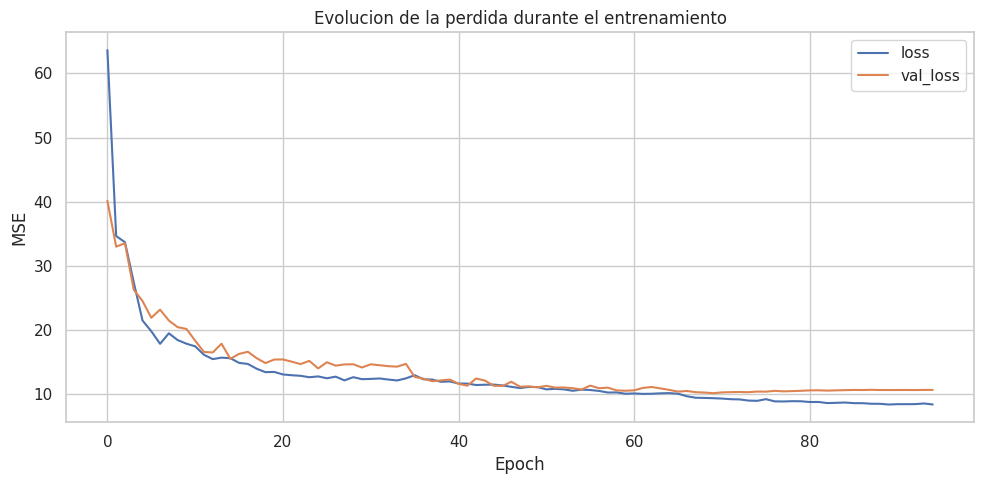

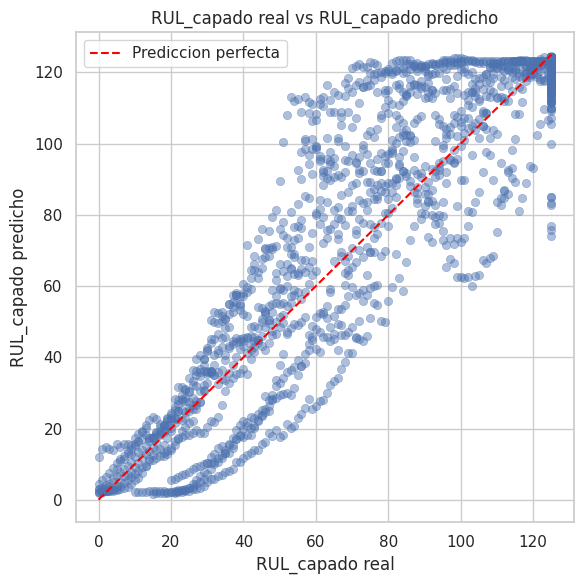

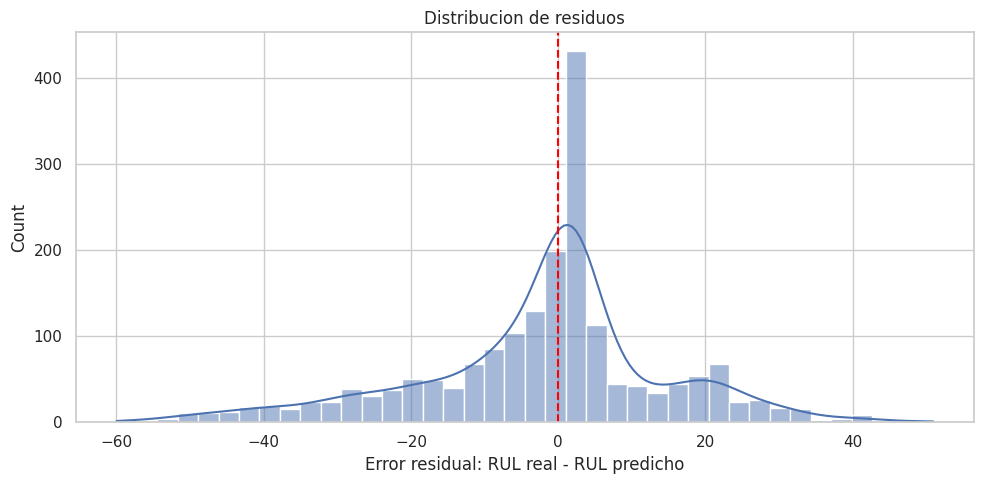

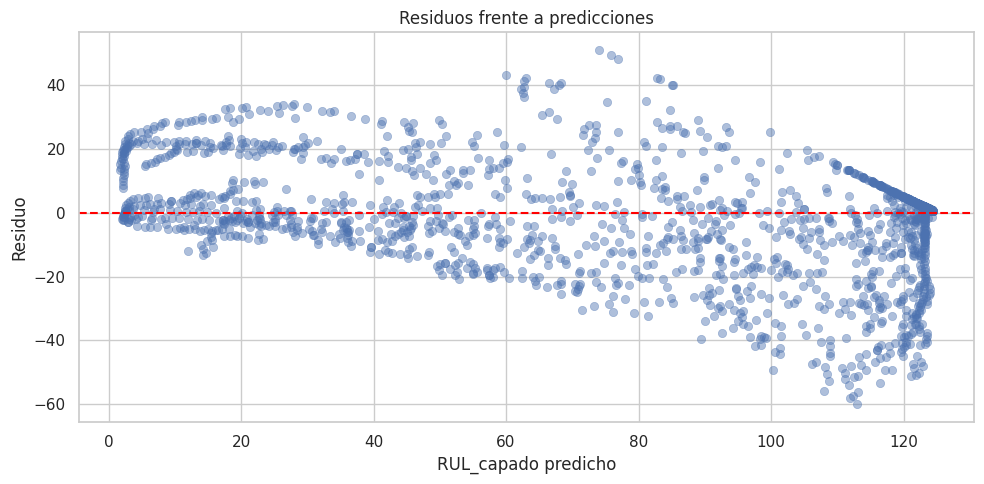

In [159]:
y_pred = model.predict(X_test, batch_size=64).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Metricas de regresion en test")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Evolucion de la perdida durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.45, edgecolor=None)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--", label="Prediccion perfecta")
plt.title("RUL_capado real vs RUL_capado predicho")
plt.xlabel("RUL_capado real")
plt.ylabel("RUL_capado predicho")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribucion de residuos")
plt.xlabel("Error residual: RUL real - RUL predicho")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.45, edgecolor=None)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos frente a predicciones")
plt.xlabel("RUL_capado predicho")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()

## 8. Conversion a niveles de riesgo

Los niveles de riesgo se derivan despues de la regresion. Esto conserva la LSTM como modelo principal de prediccion continua de RUL y permite construir una capa posterior de alertas.

In [162]:
def rul_to_risk_level(rul_values):
    """Convierte valores de RUL en niveles de riesgo operativos."""
    values = np.asarray(rul_values)
    return np.select(
        [values <= 45, (values > 45) & (values <= 90), values > 90],
        ["High risk", "Medium risk", "Low risk"],
        default="Unknown",
    )


risk_level_real = rul_to_risk_level(y_test)
risk_level_pred = rul_to_risk_level(y_pred)

risk_distribution = pd.DataFrame(
    {
        "real": pd.Series(risk_level_real).value_counts(),
        "pred": pd.Series(risk_level_pred).value_counts(),
    }
).fillna(0).astype(int)

display(risk_distribution)

,real,pred
High risk,468,467
Low risk,903,1059
Medium risk,536,381


## 9. Evaluacion de clasificacion derivada

Las metricas de clasificacion se calculan comparando los niveles de riesgo derivados del RUL real y del RUL predicho. No se entrena un clasificador independiente.

Metricas de clasificacion derivada
Accuracy:          0.7792
F1-score weighted: 0.7666

Classification report:
              precision    recall  f1-score   support

   High risk       0.86      0.86      0.86       468
 Medium risk       0.65      0.46      0.54       536
    Low risk       0.79      0.93      0.85       903

    accuracy                           0.78      1907
   macro avg       0.77      0.75      0.75      1907
weighted avg       0.77      0.78      0.77      1907



<Axes: >

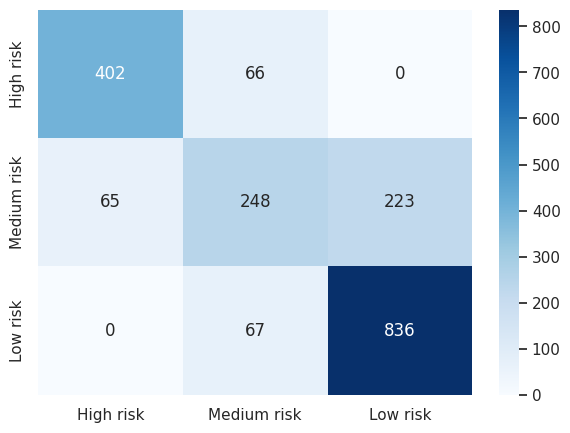

In [163]:
risk_labels = ["High risk", "Medium risk", "Low risk"]

accuracy = accuracy_score(risk_level_real, risk_level_pred)
f1_weighted = f1_score(risk_level_real, risk_level_pred, average="weighted")

print("Metricas de clasificacion derivada")
print(f"Accuracy:          {accuracy:.4f}")
print(f"F1-score weighted: {f1_weighted:.4f}")
print("\nClassification report:")
print(classification_report(risk_level_real, risk_level_pred, labels=risk_labels, zero_division=0))

cm = confusion_matrix(risk_level_real, risk_level_pred, labels=risk_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=risk_labels,
    yticklabels=risk_labels,
)

## 10. Exportacion de predicciones

Se guardan las predicciones de test junto con el motor, ciclo, RUL real, RUL predicho, niveles de riesgo y error absoluto. Este CSV puede usarse para analisis posterior, dashboards o trazabilidad del sistema de alertas.

In [164]:
results_df = test_metadata.copy()
results_df = results_df.rename(columns={unit_col: "unit_number", time_col: "time_in_cycles"})
results_df["RUL_real"] = y_test
results_df["RUL_pred"] = y_pred
results_df["risk_level_real"] = risk_level_real
results_df["risk_level_pred"] = risk_level_pred
results_df["error_abs"] = np.abs(results_df["RUL_real"] - results_df["RUL_pred"])

results_path = OUTPUT_DIR / "lstm_fd001_test_predictions.csv"
results_df.to_csv(results_path, index=False)

print(f"Predicciones guardadas en: {results_path}")
display(results_df.sample(10, random_state=random.randint(0,100)))

Predicciones guardadas en: /content/TFM_Mantenimiento_Predictivo/lstm/outputs/lstm_fd001_test_predictions.csv


,unit_number,time_in_cycles,RUL_real,RUL_pred,risk_level_real,risk_level_pred,error_abs
1263,124,94,112.0,121.718895,Low risk,Low risk,9.718895
137,10,192,30.0,35.419170,High risk,High risk,5.419170
1849,176,148,67.0,49.054939,Medium risk,Medium risk,17.945061
267,34,154,41.0,71.473396,High risk,Medium risk,30.473396
186,34,73,122.0,120.306297,Low risk,Low risk,1.693703
1606,149,236,88.0,113.934784,Medium risk,Low risk,25.934784
1287,124,118,88.0,87.850891,Medium risk,Medium risk,0.149109
1708,156,89,62.0,27.942955,Medium risk,High risk,34.057045
1388,141,87,54.0,72.890450,Medium risk,Medium risk,18.890450
382,36,128,30.0,41.658577,High risk,High risk,11.658577


In [ ]:
!git clone https://github.com/Albernio/TFM_Mantenimiento_Predictivo

Cloning into 'TFM_Mantenimiento_Predictivo'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 122 (delta 41), reused 95 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 15.84 MiB | 8.35 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [28]:
!git checkout feature/lstm
%cd "./TFM_Mantenimiento_Predictivo"

Branch 'feature/lstm' set up to track remote branch 'feature/lstm' from 'origin'.
Switched to a new branch 'feature/lstm'
[Errno 2] No such file or directory: './TFM_Mantenimiento_Predictivo'
/content/TFM_Mantenimiento_Predictivo


In [9]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
